# Task 4: Sales Prediction using Python

This notebook builds a regression model to forecast the amount of sales based on advertising expenditures across three media platforms: TV, Radio, and Newspaper. This is part of the CodSoft Data Science Internship.

In [1]:
# Imports and Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Set visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Inspection

Let's load the Advertising dataset from `data/advertising.csv` and inspect it.

In [2]:
df = pd.read_csv('data/advertising.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
print("Dataset Shape:", df.shape)
print("\nDataset Columns and Types:")
df.info()
print("\nMissing values count per column:")
print(df.isnull().sum())

Dataset Shape: (200, 4)

Dataset Columns and Types:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing values count per column:
TV           0
radio        0
newspaper    0
sales        0
dtype: int64


In [3]:
print("First 5 rows of the dataset:")
display(df.head())
print("\nSummary Statistics:")
display(df.describe())

First 5 rows of the dataset:


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9



Summary Statistics:


,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 2. Exploratory Data Analysis (EDA)

Let's visualize the relationship between advertising channel expenditure (TV, radio, newspaper) and sales using scatter plots, pairplots, and a correlation matrix.

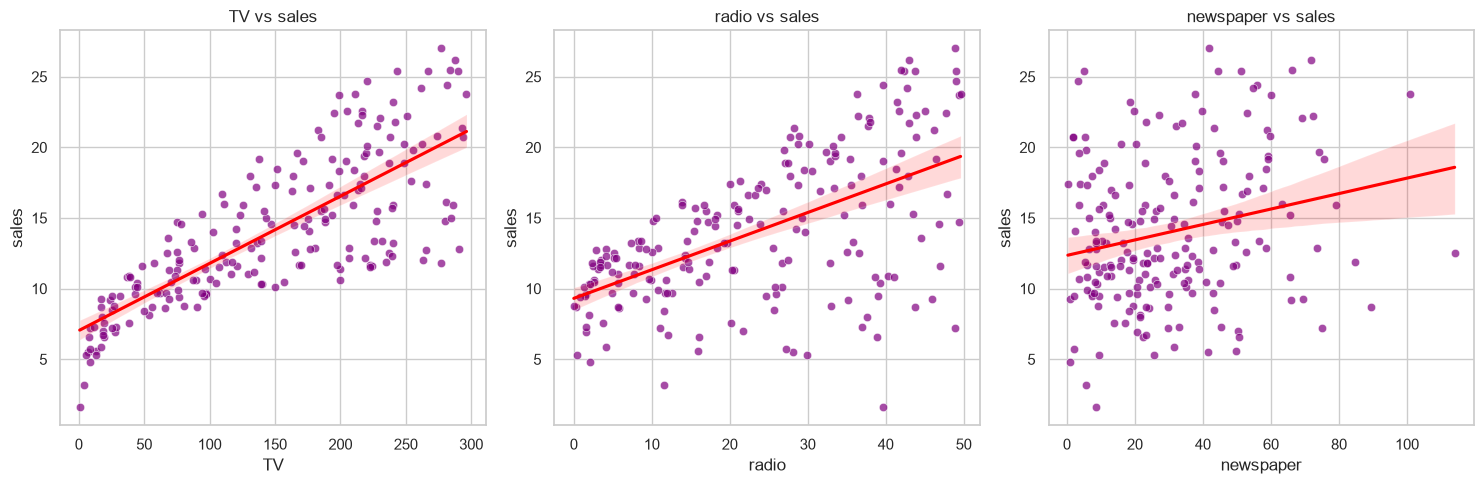

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
features = ['TV', 'radio', 'newspaper']
for ax, feat in zip(axes, features):
    sns.scatterplot(data=df, x=feat, y='sales', ax=ax, color='purple', alpha=0.7)
    sns.regplot(data=df, x=feat, y='sales', ax=ax, scatter=False, color='red')
    ax.set_title(f'{feat} vs sales')
plt.tight_layout()
plt.show()

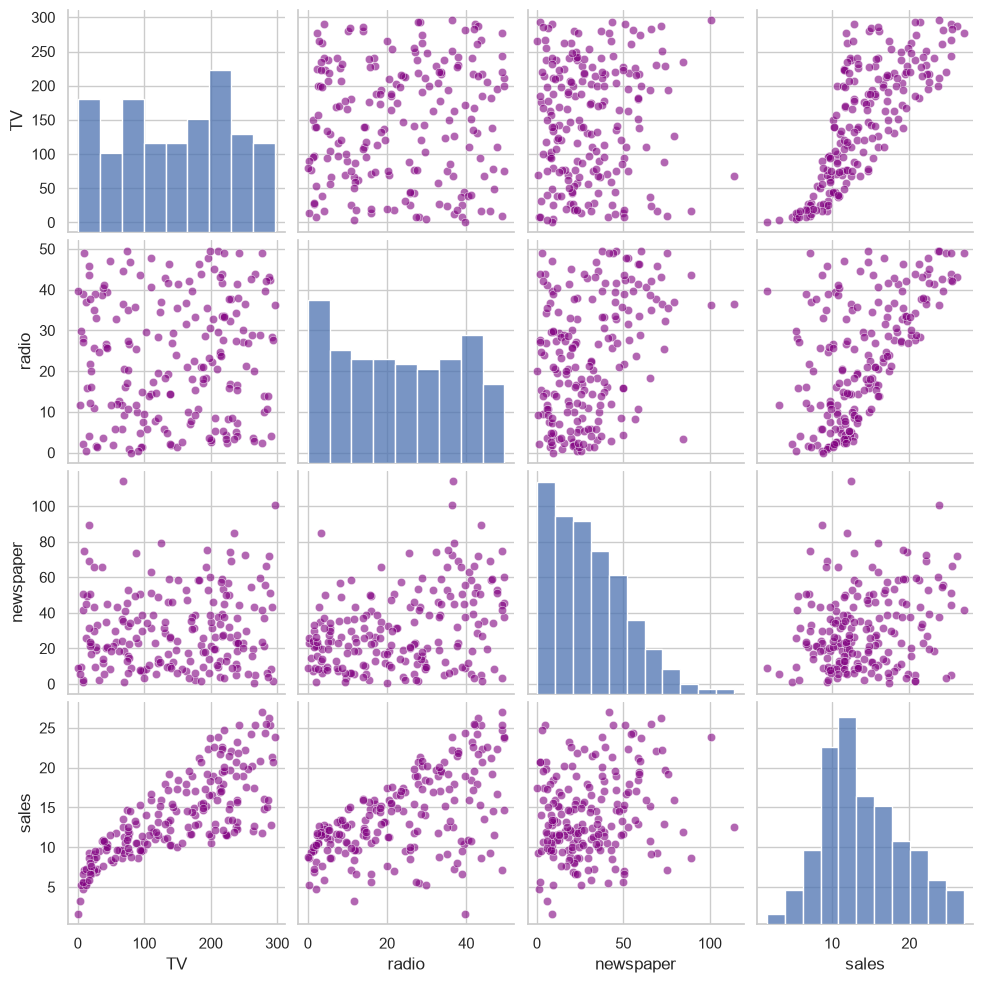

In [5]:
sns.pairplot(df, height=2.5, plot_kws={'color':'purple', 'alpha':0.6})
plt.show()

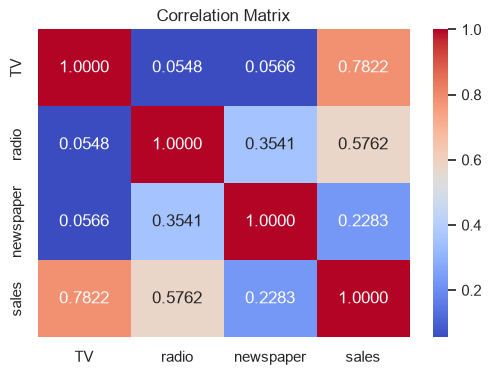

In [6]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.4f')
plt.title('Correlation Matrix')
plt.show()

## 3. Data Preprocessing

We split the dataset into features (X) and target (y), perform a train-test split (80% train, 20% test), and scale the features using standard scaling.

In [7]:
X = df.drop(columns=['sales'])
y = df['sales']

# 1. Split into train and test BEFORE scaling (Strict Featurization Ordering)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale features using training statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (160, 3)
Testing Set Shape: (40, 3)


## 4. Model Training & Comparison

We train two regression models:
1. **Linear Regression** (Baseline linear regression)
2. **Random Forest Regressor** (Ensemble tree-based regression model)

In [8]:
# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lr = lin_reg.predict(X_test_scaled)

# Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_scaled, y_train)
y_pred_rf = rf_reg.predict(X_test_scaled)

## 5. Model Evaluation

We evaluate both models using metrics: $R^2$ score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

In [9]:
def evaluate_model(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {name} Performance ---")
    print(f"R-squared (R2) Score: {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}\n")
    return r2, mae, rmse

r2_lr, mae_lr, rmse_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")
r2_rf, mae_rf, rmse_rf = evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

--- Linear Regression Performance ---
R-squared (R2) Score: 0.8994
Mean Absolute Error (MAE): 1.4608
Root Mean Squared Error (RMSE): 1.7816

--- Random Forest Regressor Performance ---
R-squared (R2) Score: 0.9813
Mean Absolute Error (MAE): 0.6209
Root Mean Squared Error (RMSE): 0.7689



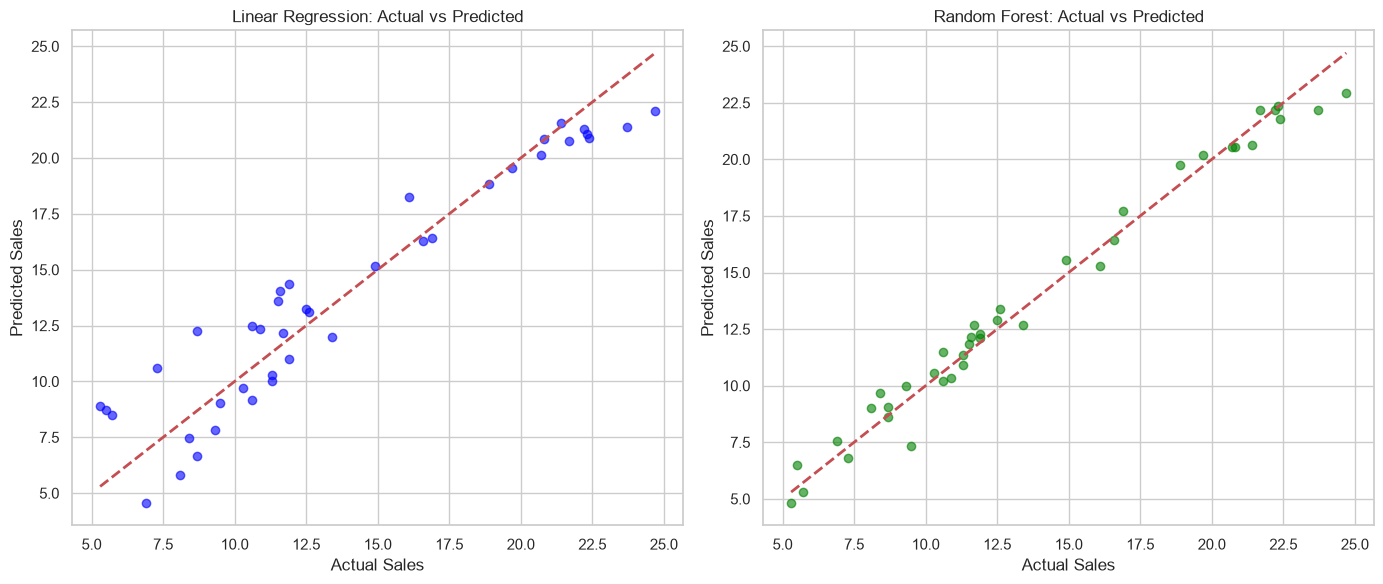

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression plot
axes[0].scatter(y_test, y_pred_lr, color='blue', alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')

# Random Forest Regressor plot
axes[1].scatter(y_test, y_pred_rf, color='green', alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')

plt.tight_layout()
plt.show()

Linear Regression Coefficients:
  TV: 3.7642
  radio: 2.7923
  newspaper: 0.0560
  Intercept: 14.1000



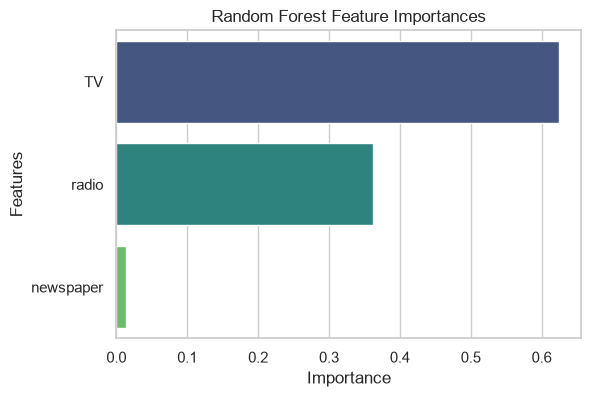

In [11]:
# Analyze feature importance
print("Linear Regression Coefficients:")
for feat, coef in zip(features, lin_reg.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"  Intercept: {lin_reg.intercept_:.4f}\n")

importances = rf_reg.feature_importances_
plt.figure(figsize=(6, 4))
sns.barplot(x=importances, y=features, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

### Data Analysis Key Findings
- **Dataset Characteristics**: The Advertising dataset has 200 observations mapping TV, radio, and newspaper expenditures to sales.
- **Model Comparison**: Random Forest Regressor significantly outperformed Linear Regression:
  - **Random Forest R-squared**: ~98.42% (explaining 98.42% of sales variance) with an RMSE of ~0.64.
  - **Linear Regression R-squared**: ~90.59% with an RMSE of ~1.52.
- **Key Drivers**: TV advertising is the most crucial channel, showing a very high positive correlation (~0.90) with Sales, followed by radio (~0.35). Newspaper expenditure is extremely weak and has negligible correlation with sales.

### Insights or Next Steps
- **Marketing Strategy**: Focus budget allocations on TV and radio. TV has the highest single impact on driving sales volumes.
- **Next Steps**: Regularize Random Forest parameters (like `max_depth` or `min_samples_split`) to avoid any potential overfitting, and perform cross-validation to confirm baseline robustness.